['gcag' 'GISTEMP']
Final shape: (175, 3)


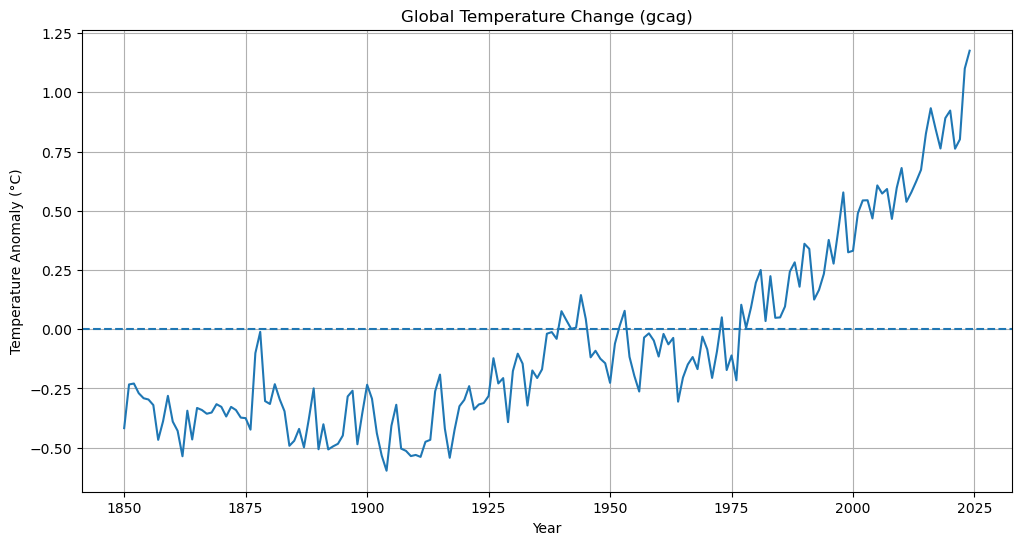

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasets/global-temp/master/data/annual.csv"
df = pd.read_csv(url)

# See what's available
print(df["Source"].unique())

# Pick one dynamically (safe)
source = df["Source"].unique()[0]
df = df[df["Source"] == source]

# Clean
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Mean"] = pd.to_numeric(df["Mean"], errors="coerce")
df = df.dropna(subset=["Year", "Mean"])

# Sort
df = df.sort_values("Year")

print("Final shape:", df.shape)  # should NOT be (0, ...)

# Plot
plt.figure(figsize=(12,6))
plt.plot(df["Year"], df["Mean"])

plt.axhline(0, linestyle="--")
plt.title(f"Global Temperature Change ({source})")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid(True)

plt.show()